# Lab 3: Recent Climate Trends in Colorado Springs
This Jupyter notebook allows you to complete Lab 3 (EV128, Colorado College) by analyzing, visualizing, and interpreting data from Colorado Springs.

Jupyter notebooks act as a wrapper for Python code. The notebook includes documentation that explains where and how to change the code to refine figures and analyze data. No prior familiarity (aside from Lab 2) with Jupyter notebooks or Python is needed for this lab.

**Guidelines and questions to complete are found in the document on Canvas.** Submit your lab writeup only--there is no need to submit your version of this notebook.

We use the Colab environment to interact with code from within your web browser. **Colab environments are temporary.** If you have made changes to your code that you want to save to use on the second day of lab, please copy and paste these into a separate program (e.g., a Word document). There are many other ways to interact with code, but they are beyond the scope of this class.

Each cell with code (computer code is denoted in `this font`) is run by clicking the "Play" button on the left side which appears when you hover over the cell. 

Begin by running the cell below to define pre-written functions (which carry out tasks) and packages (collections of many functions) for analysis. You will know that a cell completed successfully when a small green checkmark appears to the left of the cell.

In [80]:
#  DO NOT EDIT CODE IN THIS CELL
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

def make_base_figure():
    ''' Make base figure with set parameters for analysis '''
    fig, ax = plt.subplots(1, 1)
    fig.set_figwidth(15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.rcParams["font.size"] = 14
    
    return fig, ax

def make_wide_figure():
    ''' Make wide base figure with set parameters for analysis '''
    fig, ax = plt.subplots(1, 1)
    fig.set_figwidth(45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.rcParams["font.size"] = 14
    
    return fig, ax

## Part 1: Daily Climate Data

### Import daily data
In this case, we will begin by downloading the data (e.g., transferring it via the Internet from a server, in this case Canvas, that stores data in another location to your local computer) and import it (open the data for analysis in a software environment such as a Jupyter notebook, Excel, or ArcGIS). 

*Before running the cell below, you must download the data from Canvas and locate it on your computer.*


In [ ]:
from google.colab import files
uploaded = files.upload()
data_path = '/Users/danielhueholt/Data/ev128_data/Lab3/'

In [ ]:

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL
cos_daily = 'CO_Springs_weather_data_updated2025_DAILY.csv'
df = pd.read_csv(data_path + cos_daily)
df_dates = df.Date
df_temp_max = df.Temp_max
df_temp_min = df.Temp_min


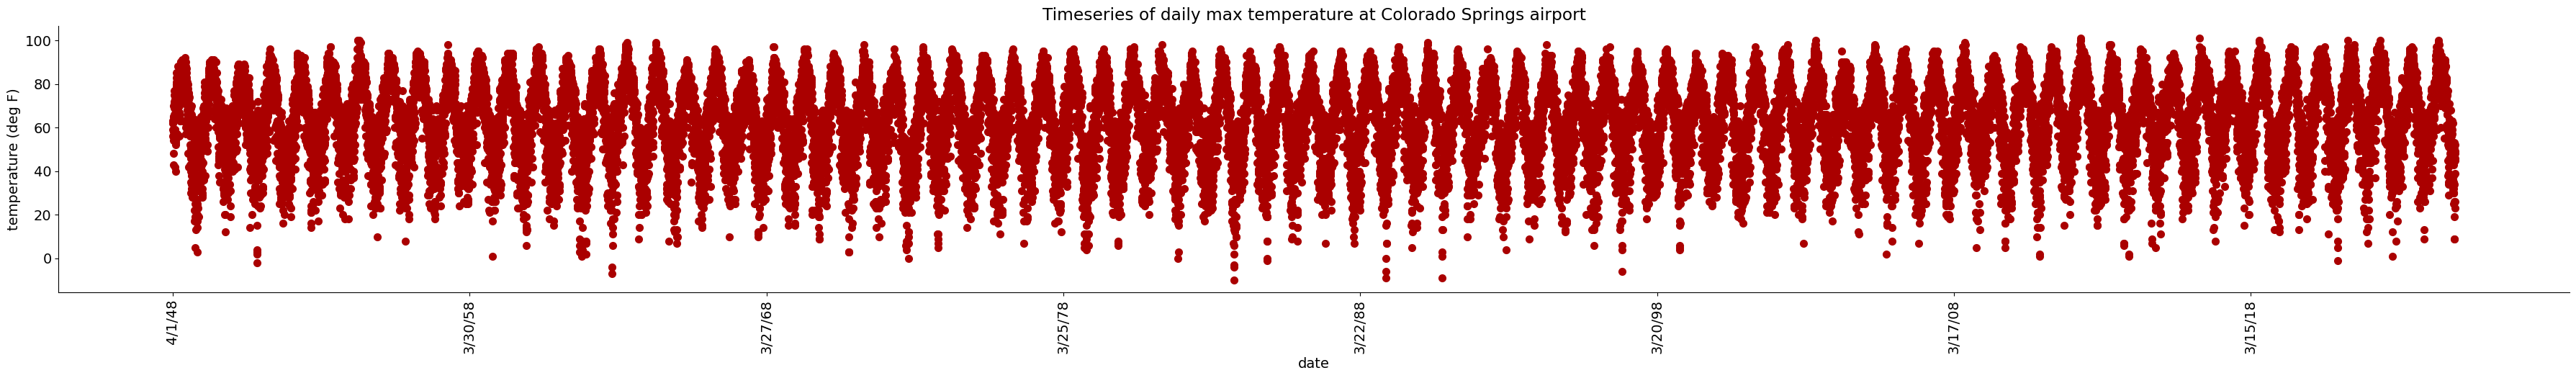

In [82]:
# Run this cell to generate the first figure of daily temperature data
#  Visual parameters
x_axis_label = 'date'
y_axis_label = 'temperature (deg F)'
title_message = 'Timeseries of daily max temperature at Colorado Springs airport'

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL
fig, ax = make_wide_figure()

plt.scatter(df_dates, df_temp_max, color='#aa0000', lw=2)
plt.title(title_message)
plt.xlabel(x_axis_label)
plt.xticks(range(0, len(df_dates), 3650), df_dates[::3650], rotation = 90)
plt.ylabel(y_axis_label)
plt.show()

In [83]:
# Print information about max and min
#  DO NOT CHANGE THIS CELL
maximum_in_record = np.max(df_temp_max)
maximum_in_record_dates = df_dates[df_temp_max == maximum_in_record]
minimum_in_record = np.min(df_temp_min)
minimum_in_record_dates = df_dates[df_temp_min == minimum_in_record]

print('Maximum daily temperature: ' + str(np.round(maximum_in_record)))
for each_max_date in maximum_in_record_dates:
    print('Maximum daily temperature occurred on: ' + str(each_max_date))
print('Minimum daily temperature: ' + str(np.round(minimum_in_record)))
for each_min_date in minimum_in_record_dates:
    print('Minimum daily temperature occurred on: ' + str(each_min_date))

Maximum daily temperature: 101.0
Maximum daily temperature occurred on: 6/26/12
Maximum daily temperature occurred on: 6/21/16
Minimum daily temperature: -27.0
Minimum daily temperature occurred on: 2/1/51


R2 value: 0.001527
Slope: 9.1e-05
Equation: y=9.1e-05x + 61.576896


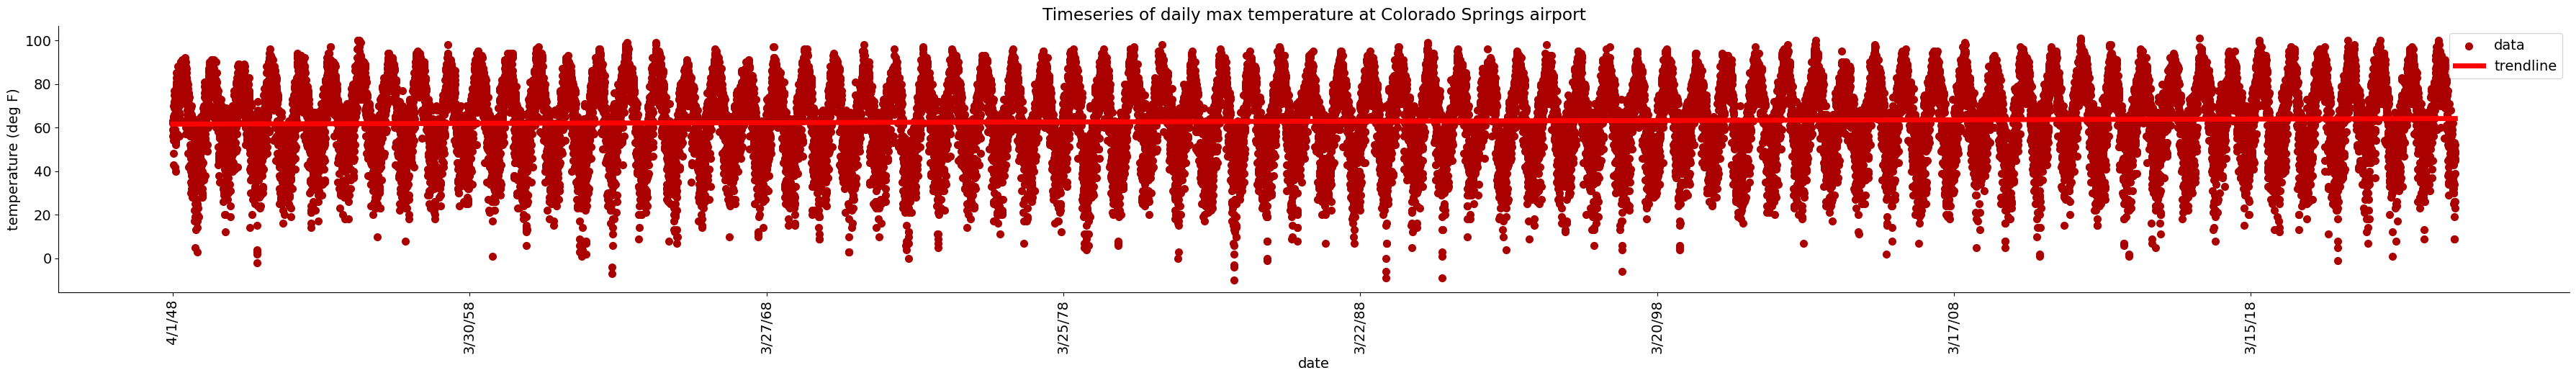

In [84]:
# Run this cell to generate the daily temperature data with a trendline
#  Visual parameters
x_axis_label = 'date'
y_axis_label = 'temperature (deg F)'
title_message = 'Timeseries of daily max temperature at Colorado Springs airport'
trendline_color = 'red'
trendline_label = 'trendline'

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL

# Calculate linear regression
arb_x = np.arange(0, len(df_dates))
res = stats.linregress(arb_x, df_temp_max, nan_policy='omit')
res_line = res.intercept + res.slope * arb_x
print("R2 value: " + str(np.round(res.rvalue ** 2, 6)))
print("Slope: " + str(np.round(res.slope, 6)))
print("Equation: y=" + str(np.round(res.slope, 6)) + 'x + ' + str(np.round(res.intercept, 6)))

# Make plot
fig, ax = make_wide_figure()
plt.scatter(arb_x, df_temp_max, color='#aa0000', lw=2, label='data')
plt.plot(arb_x, res_line, trendline_color, label=trendline_label, lw=5)
plt.legend()
plt.title(title_message)
plt.xlabel(x_axis_label)
plt.xticks(range(0, len(df_dates), 3650), df_dates[::3650], rotation = 90)
plt.ylabel(y_axis_label)
plt.show()

The next cell now makes the same kind of figure, but for daily MINIMUM temperature instead of maximum.

R2 value: 0.001449
Slope: 7.7e-05
Equation: y=7.7e-05x + 34.868486


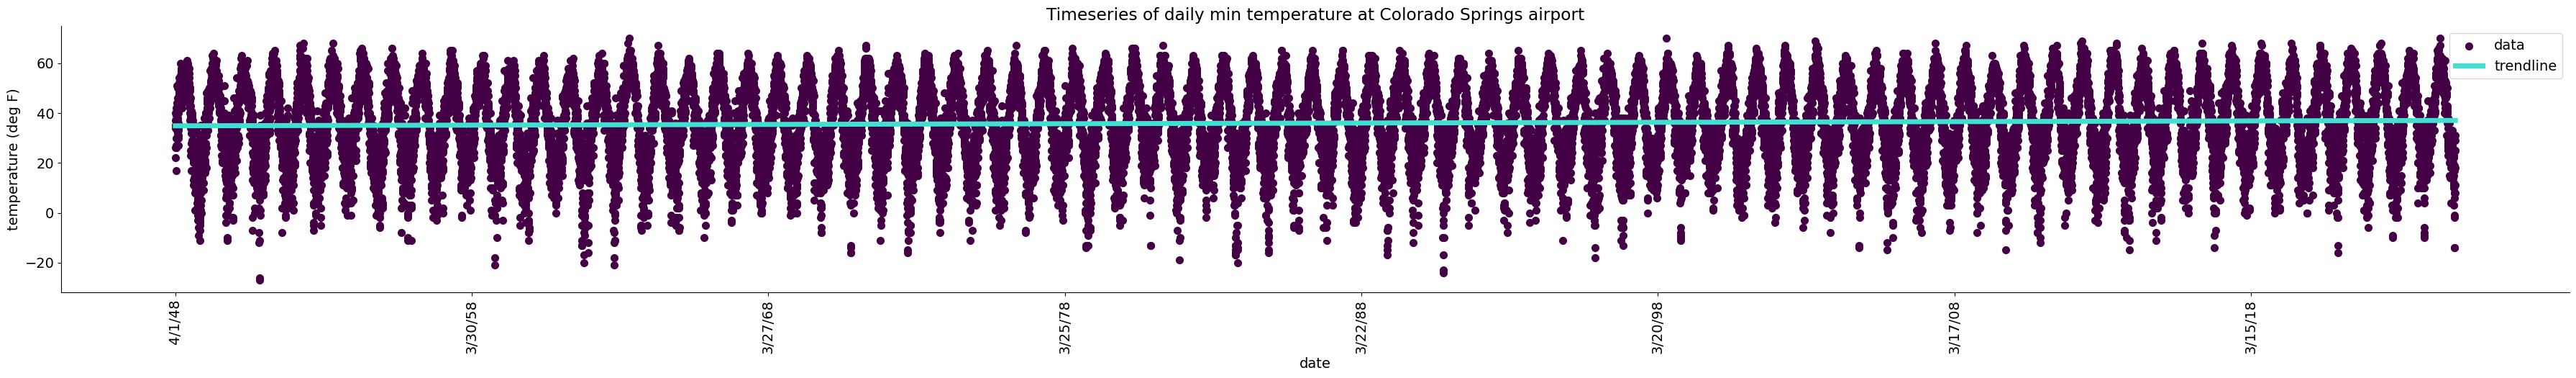

In [85]:
# Run this cell to generate the daily temperature data with a trendline
#  Visual parameters
x_axis_label = 'date'
y_axis_label = 'temperature (deg F)'
title_message = 'Timeseries of daily min temperature at Colorado Springs airport'
trendline_color = 'turquoise'
trendline_label = 'trendline'

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL

# Calculate linear regression
arb_x = np.arange(0, len(df_dates))
res = stats.linregress(arb_x, df_temp_min, nan_policy='omit')
res_line = res.intercept + res.slope * arb_x
print("R2 value: " + str(np.round(res.rvalue ** 2, 6)))
print("Slope: " + str(np.round(res.slope, 6)))
print("Equation: y=" + str(np.round(res.slope, 6)) + 'x + ' + str(np.round(res.intercept, 6)))

# Make plot
fig, ax = make_wide_figure()
plt.scatter(arb_x, df_temp_min, color='#440044', lw=2, label='data')
plt.plot(arb_x, res_line, trendline_color, label=trendline_label, lw=5)
plt.legend()
plt.title(title_message)
plt.xlabel(x_axis_label)
plt.xticks(range(0, len(df_dates), 3650), df_dates[::3650], rotation = 90)
plt.ylabel(y_axis_label)
plt.show()

## Part 2: Annual Climate Data
### Import annual data
In this case, we will begin by downloading the data (e.g., transferring it via the Internet from a server, in this case Canvas, that stores data in another location to your local computer) and import it (open the data for analysis in a software environment such as a Jupyter notebook, Excel, or ArcGIS). 

*Before running the cell below, you must download the data from Canvas and locate it on your computer.*


In [ ]:
#  DO NOT CHANGE THIS CELL
cos_annual = 'CO_Springs_weather_data_updated2025_ANNUAL.csv'
df = pd.read_csv(data_path + cos_annual)
df_dates = df.Date
df_temp_ann_max = df.Temp_avg_daily_max
df_temp_ann_min = df.Temp_avg_daily_min


R2 value: 0.228208
Slope: 0.038883
Equation: y=0.038883x + 61.369515


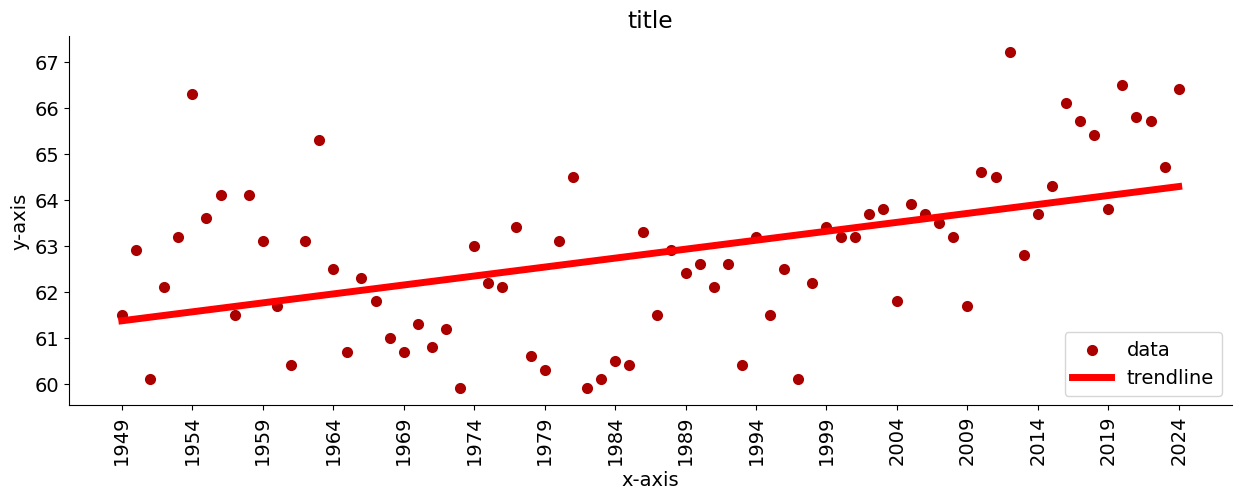

In [91]:
# Run this cell to generate the annual average maximum temperature data with a trendline
#  Visual parameters
x_axis_label = 'x-axis' #  PART 2, Q1: Label the x-axis. Change the text inside the '' symbols.
y_axis_label = 'y-axis' #  PART 2, Q1: Label the y-axis. Change the text inside the '' symbols.
title_message = 'title' #  PART 2, Q1: Label the title. Change the text inside the '' symbols.
trendline_color = 'red'
trendline_label = 'trendline'

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL

# Calculate linear regression
arb_x = np.arange(0, len(df_dates))
res = stats.linregress(arb_x, df_temp_ann_max, nan_policy='omit')
res_line = res.intercept + res.slope * arb_x
print("R2 value: " + str(np.round(res.rvalue ** 2, 6)))
print("Slope: " + str(np.round(res.slope, 6)))
print("Equation: y=" + str(np.round(res.slope, 6)) + 'x + ' + str(np.round(res.intercept, 6)))

# Make plot
fig, ax = make_base_figure()
plt.scatter(arb_x, df_temp_ann_max, color='#aa0000', lw=2, label='data')
plt.plot(arb_x, res_line, trendline_color, label=trendline_label, lw=5)
plt.legend()
plt.title(title_message)
plt.xlabel(x_axis_label)
plt.xticks(range(0, len(df_dates), 5), df_dates[::5], rotation = 90)
plt.ylabel(y_axis_label)
plt.show()

In [93]:
#  DO NOT CHANGE THIS CELL
maximum_in_record = np.max(df_temp_ann_max)
maximum_in_record_dates = df_dates[df_temp_ann_max == maximum_in_record]
minimum_in_record = np.min(df_temp_ann_max)
minimum_in_record_dates = df_dates[df_temp_ann_max == minimum_in_record]

print('Highest average annual max temperature: ' + str(np.round(maximum_in_record)))
for each_max_date in maximum_in_record_dates:
    print('Highest average annual max temperature occurred: ' + str(each_max_date))
print('Lowest average annual max temperature: ' + str(np.round(minimum_in_record)))
for each_min_date in minimum_in_record_dates:
    print('Lowest average annual max temperature occurred: ' + str(each_min_date))

Highest average annual max temperature: 67.0
Highest average annual max temperature occurred: 2012
Lowest average annual max temperature: 60.0
Lowest average annual max temperature occurred: 1973
Lowest average annual max temperature occurred: 1982


R2 value: 0.338834
Slope: 0.032648
Equation: y=0.032648x + 34.704648


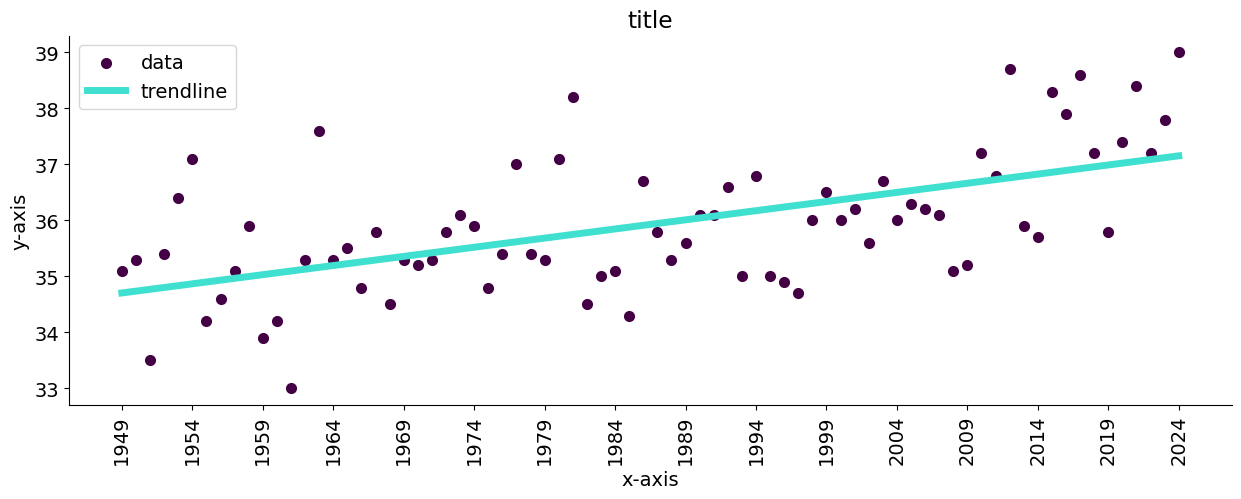

In [ ]:
# Run this cell to generate the annual average minimum temperature data with a trendline
#  Visual parameters
x_axis_label = 'x-axis' #  PART 2, Q2: Label the x-axis. Change the text inside the '' symbols.
y_axis_label = 'y-axis' #  PART 2, Q2: Label the y-axis. Change the text inside the '' symbols.
title_message = 'title' #  PART 2, Q2: Label the title. Change the text inside the '' symbols.
trendline_color = 'turquoise'
trendline_label = 'trendline'

#  DO NOT CHANGE BELOW THIS LINE IN THIS CELL

# Calculate linear regression
arb_x = np.arange(0, len(df_dates))
res = stats.linregress(arb_x, df_temp_ann_min, nan_policy='omit')
res_line = res.intercept + res.slope * arb_x
print("R2 value: " + str(np.round(res.rvalue ** 2, 6)))
print("Slope: " + str(np.round(res.slope, 6)))
print("Equation: y=" + str(np.round(res.slope, 6)) + 'x + ' + str(np.round(res.intercept, 6)))

# Make plot
fig, ax = make_base_figure()
plt.scatter(arb_x, df_temp_ann_min, color='#440044', lw=2, label='data')
plt.plot(arb_x, res_line, trendline_color, label=trendline_label, lw=5)
plt.legend()
plt.title(title_message)
plt.xlabel(x_axis_label)
plt.xticks(range(0, len(df_dates), 5), df_dates[::5], rotation = 90)
plt.ylabel(y_axis_label)
plt.show()

In [95]:
#  DO NOT CHANGE THIS CELL
maximum_in_record = np.max(df_temp_ann_min)
maximum_in_record_dates = df_dates[df_temp_ann_min == maximum_in_record]
minimum_in_record = np.min(df_temp_ann_min)
minimum_in_record_dates = df_dates[df_temp_ann_min == minimum_in_record]

print('Highest average annual min temperature: ' + str(np.round(maximum_in_record)))
for each_max_date in maximum_in_record_dates:
    print('Highest average annual min temperature occurred: ' + str(each_max_date))
print('Lowest average annual min temperature: ' + str(np.round(minimum_in_record)))
for each_min_date in minimum_in_record_dates:
    print('Lowest average annual min temperature occurred: ' + str(each_min_date))

Highest average annual min temperature: 39.0
Highest average annual min temperature occurred: 2024
Lowest average annual min temperature: 33.0
Lowest average annual min temperature occurred: 1961


## Part 3: January Climate Data
### Import January data
In this case, we will begin by downloading the data (e.g., transferring it via the Internet from a server, in this case Canvas, that stores data in another location to your local computer) and import it (open the data for analysis in a software environment such as a Jupyter notebook, Excel, or ArcGIS). 

*Before running the cell below, you must download the data from Canvas and locate it on your computer.*


In [ ]:
#  DO NOT CHANGE THIS CELL
cos_january = 'CO_Springs_weather_data_updated2025_JANUARY.csv'
df = pd.read_csv(data_path + cos_january)
df_dates = df.Date
df_temp_jan_max = df.Temp_max
df_temp_jan_min = df.Temp_min


In [103]:
avg_daily_max = np.nanmean(df_temp_jan_max)
print("Average daily max in January: " + str(np.round(avg_daily_max, 2)))

Average daily max in January: 44.71


In [104]:
#  If you would like to attempt calculating the lapse rate in the code, you can do so in this cell